# Exploring expected goals (xG) in the Premier League

#### Data Scraping

In [2]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

url = "https://fantasy.premierleague.com/api/bootstrap-static/"

response = requests.get(url)
data = response.json()

players = pd.DataFrame(data["elements"])
teams = pd.DataFrame(data["teams"])

team_map = teams.set_index("id")["name"]
players["team_name"] = players["team"].map(team_map)

df = players[[
    "web_name",
    "team_name",
    "goals_scored",
    "expected_goals",
    "minutes"
]].copy()

df = df.rename(columns={
    "web_name": "player",
    "team_name": "team",
    "goals_scored": "goals",
    "expected_goals": "xg"
})

df["goals"] = pd.to_numeric(df["goals"], errors="coerce")
df["xg"] = pd.to_numeric(df["xg"], errors="coerce")
df["minutes"] = pd.to_numeric(df["minutes"], errors="coerce")

df["goals_minus_xg"] = df["goals"] - df["xg"]

df

,player,team,goals,xg,minutes,goals_minus_xg
0,Raya,Arsenal,0,0.00,3150,0.00
1,Arrizabalaga,Arsenal,0,0.00,0,0.00
2,Hein,Arsenal,0,0.00,0,0.00
3,Setford,Arsenal,0,0.00,0,0.00
4,Gabriel,Arsenal,3,2.64,2525,0.36
...,...,...,...,...,...,...
827,Abbey,Wolves,0,0.00,0,0.00
828,Angel,Wolves,0,0.21,391,-0.21
829,Armstrong,Wolves,1,1.56,907,-0.56
830,Brooks,Wolves,0,0.00,0,0.00


#### Sorting and Analysis

In [4]:
top = (df.sort_values("goals_minus_xg", ascending=False))
bottom = (df.sort_values("goals_minus_xg"))

print(bottom.head(5))
print(top.head(5))

        player            team  goals     xg  minutes  goals_minus_xg
147     Brooks     Bournemouth      1   5.16     1171           -4.16
194     Schade       Brentford      7  10.96     2537           -3.96
158  Evanilson     Bournemouth      6   9.80     2539           -3.80
293      Delap         Chelsea      1   4.48      999           -3.48
330     Mateta  Crystal Palace     10  13.45     2084           -3.45
            player         team  goals     xg  minutes  goals_minus_xg
489        Semenyo     Man City     15  10.66     2908            4.34
397         Wilson       Fulham     10   5.71     2584            4.29
161      Kroupi.Jr  Bournemouth     12   7.86     1438            4.14
346  Dewsbury-Hall      Everton      8   3.88     2366            4.12
591       Bruno G.    Newcastle      9   5.08     2211            3.92


#### Results and Visualization

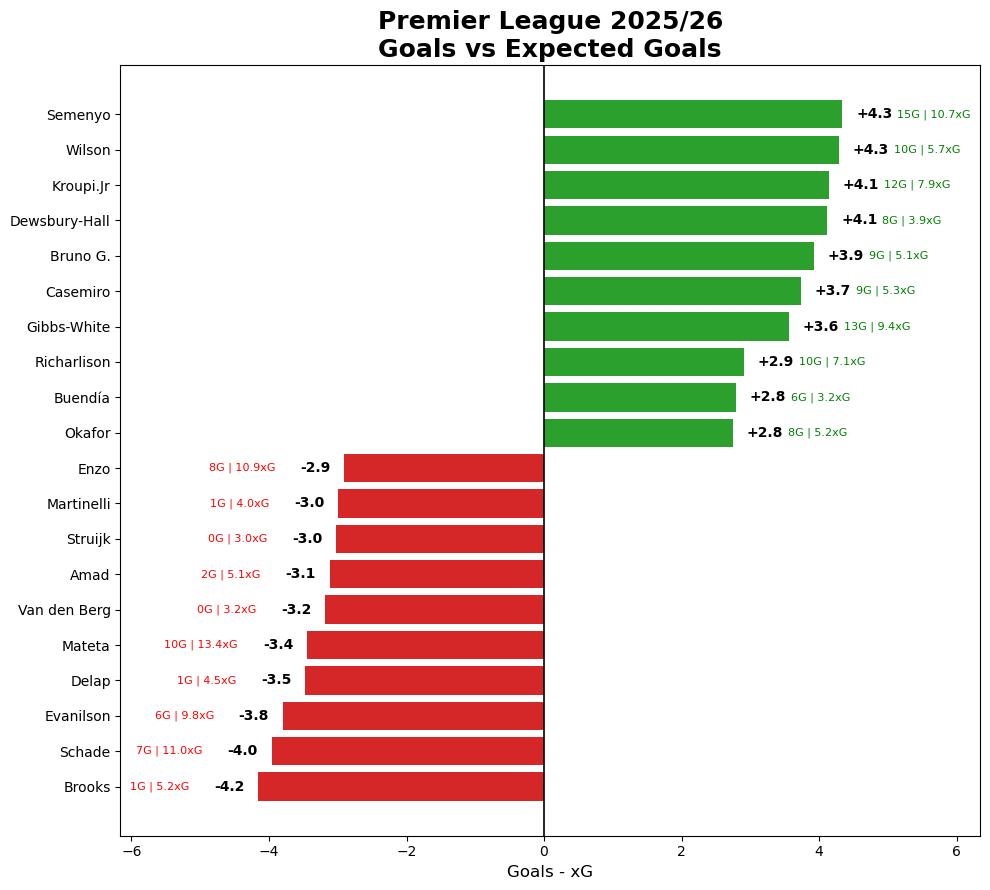

In [5]:
import matplotlib.pyplot as plt

filtered = df.copy()

top10 = filtered.nlargest(10, "goals_minus_xg")
bottom10 = filtered.nsmallest(10, "goals_minus_xg")

plot_df = pd.concat([bottom10, top10]).sort_values("goals_minus_xg")

plt.figure(figsize=(10, 9))

colors = ["#d62728" if x < 0 else "#2ca02c" for x in plot_df["goals_minus_xg"]]

bars = plt.barh(plot_df["player"], plot_df["goals_minus_xg"], color=colors)

plt.axvline(0, color="black", linewidth=1.2)

plt.title("Premier League 2025/26\nGoals vs Expected Goals", fontsize=18, weight="bold")
plt.xlabel("Goals - xG", fontsize=12)

for i, row in enumerate(plot_df.itertuples()):
    value = row.goals_minus_xg
    
    label_main = f"{value:+.1f}"
    label_sub = f"{int(row.goals)}G | {row.xg:.1f}xG"

    if value < 0:
        plt.text(value - 0.2, i, label_main, va="center", ha="right", fontsize=10, weight="bold")
        plt.text(value - 1.0, i, label_sub, va="center", ha="right", fontsize=8, color="red")
    else:
        plt.text(value + 0.2, i, label_main, va="center", ha="left", fontsize=10, weight="bold")
        plt.text(value + 0.8, i, label_sub, va="center", ha="left", fontsize=8, color="green")

plt.xlim(plot_df["goals_minus_xg"].min() - 2, plot_df["goals_minus_xg"].max() + 2)

plt.tight_layout()
plt.show()